<a href="https://colab.research.google.com/github/RajolKumar2003/Computer-Log-Anomaly-Detection/blob/dataset-code/Medium_Dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

This cell imports the `pandas` and `numpy` libraries, which are essential for data manipulation and numerical operations in Python.

In [ ]:
import pandas as pd
import numpy as np

This cell imports additional libraries including `matplotlib.pyplot` for plotting, `seaborn` for enhanced visualizations, `sklearn.model_selection` for splitting data, `sklearn.preprocessing` for data scaling, `sklearn.ensemble` for anomaly detection models, and `sklearn.metrics` for evaluating model performance.

This cell mounts Google Drive to access files stored in your Drive, making it possible to load datasets directly from your cloud storage.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell defines the file path for the dataset `02-15-2018.csv` located in Google Drive and prints the path for verification.

In [ ]:
file_path = '/content/drive/MyDrive/02-15-2018.csv'

print("Dataset path:")
print(file_path)

Dataset path:
/content/drive/MyDrive/02-15-2018.csv


This cell loads the dataset from the specified file path into a pandas DataFrame. `low_memory=False` is used to prevent potential Dtype warnings for mixed types in columns.

In [ ]:
print("Loading dataset...")

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")

Loading dataset...
Dataset loaded successfully.


This cell displays the first 5 rows of the loaded DataFrame to give a quick overview of its structure and data.

In [ ]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


This cell retrieves and displays all column names of the DataFrame as a list, which is useful for understanding the dataset's features.

In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

This cell provides a concise summary of the DataFrame, including the column names, their non-null counts, and data types, along with memory usage. This helps identify columns with missing values and incorrect data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

This cell removes the 'Timestamp' column from the DataFrame as it's not needed for the subsequent analysis. `inplace=True` modifies the DataFrame directly.

In [ ]:
df.drop('Timestamp', axis=1, inplace=True)
print("'Timestamp' column removed successfully.")

'Timestamp' column removed successfully.


This cell calculates and displays the count of each unique value in the 'Label' column, providing insight into the distribution of different attack types and benign traffic.

In [ ]:
df['Label'].value_counts()

,count
Label,
Benign,996077
DoS attacks-GoldenEye,41508
DoS attacks-Slowloris,10990


This cell generates a pie chart to visualize the distribution of labels in the dataset, showing the proportion of benign and different attack types.

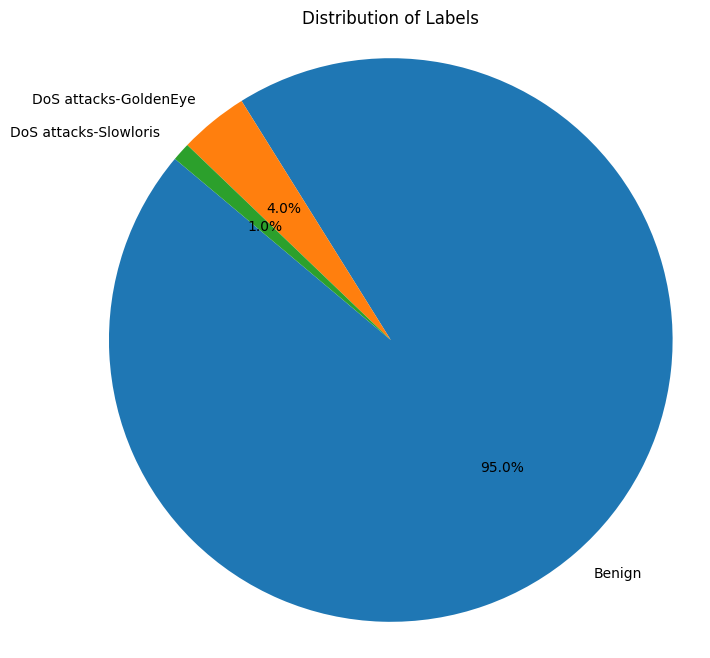

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell removes rows where the 'Label' is 'DoS attacks-Slowloris' from the DataFrame. It then prints the number of rows removed and the new shape of the DataFrame.

In [ ]:
initial_rows = len(df)
df = df[df['Label'] != 'DoS attacks-Slowloris']
removed_rows = initial_rows - len(df)
print(f"Removed {removed_rows} rows labeled 'DoS attacks-Slowloris'.")
print(f"New DataFrame shape: {df.shape}")

Removed 10990 rows labeled 'DoS attacks-Slowloris'.
New DataFrame shape: (1037585, 79)


This cell regenerates the pie chart after removing 'DoS attacks-Slowloris' to show the updated distribution of labels, including both counts and percentages.

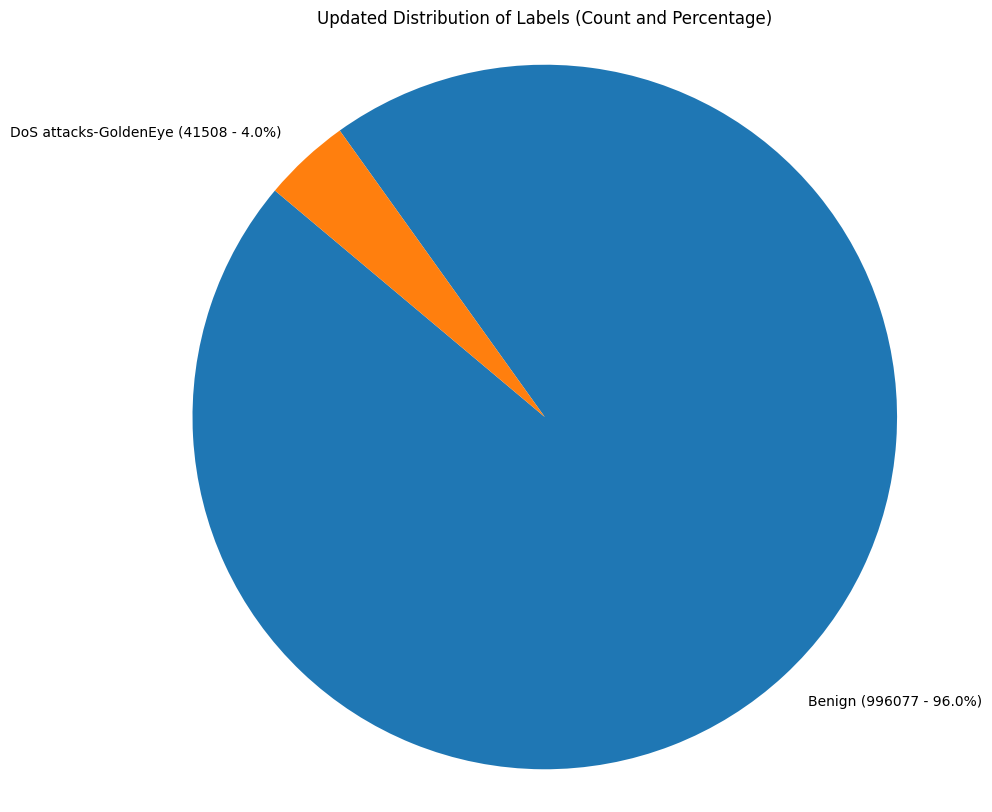

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell checks for duplicate rows in the DataFrame and calculates the number and percentage of duplicates. This step is crucial for data cleaning.

In [ ]:
duplicate_rows = df.duplicated().sum()
total_rows = len(df)
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Total number of rows: {total_rows}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 162835
Total number of rows: 1037585
Percentage of duplicate rows: 15.69%


This cell displays all identified duplicate records in the DataFrame, allowing for inspection before removal.

In [ ]:
print("Duplicate records:")
duplicate_records = df[df.duplicated()]
display(duplicate_records)

Duplicate records:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
12290,80,6,1968873,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13026,80,6,1947540,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13146,80,6,9003609,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9003609.0,0.0,9003609,9003609,DoS attacks-GoldenEye
13392,80,6,9000561,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9000561.0,0.0,9000561,9000561,DoS attacks-GoldenEye
14374,80,6,1954456,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048478,80,6,113,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048488,443,6,142,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048490,80,6,97,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048553,443,6,219,3,0,77,0,46,0,25.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


This cell removes all duplicate rows from the DataFrame, ensuring that only unique records are retained for analysis.

In [ ]:
print("Removing duplicate rows...")
df.drop_duplicates(inplace=True)
print(f"DataFrame now has {len(df)} distinct rows.")

Removing duplicate rows...
DataFrame now has 874750 distinct rows.


This cell checks for missing values in the DataFrame and displays only those columns that have at least one missing value. This helps in understanding data completeness.

In [ ]:
print("Missing values in the DataFrame:")
missing_values = df.isnull().sum()
# Display only columns with missing values
display(missing_values[missing_values > 0])


Missing values in the DataFrame:


,0
Flow Byts/s,4759


This cell calculates and displays the percentage of missing values for columns that contain them, providing a clearer picture of the extent of missing data.

In [ ]:
print("Percentage of missing values in the DataFrame:")
missing_percentage = (missing_values / len(df)) * 100
# Display only columns with missing values and their percentages
display(missing_percentage[missing_percentage > 0])

Percentage of missing values in the DataFrame:


,0
Flow Byts/s,0.544041


This cell handles missing values in the 'Flow Byts/s' column by imputing them with the median value grouped by their respective 'Label'. This ensures that missing data is filled appropriately without distorting the label-specific distributions.

In [ ]:
# Check labels associated with missing 'Flow Byts/s' values
print("Labels for rows with missing 'Flow Byts/s' values:")
display(df[df['Flow Byts/s'].isnull()]['Label'].value_counts())

# Calculate median 'Flow Byts/s' for each label
median_flow_byts_per_label = df.groupby('Label')['Flow Byts/s'].median()
print("\nMedian 'Flow Byts/s' for each label:")
display(median_flow_byts_per_label)

# Impute missing 'Flow Byts/s' values based on the median of their respective label
for label, median_value in median_flow_byts_per_label.items():
    df.loc[(df['Label'] == label) & (df['Flow Byts/s'].isnull()), 'Flow Byts/s'] = median_value

print("\nMissing values in 'Flow Byts/s' imputed successfully.")
# Verify that there are no more missing values in 'Flow Byts/s'
print("\nMissing values after imputation:")
display(df['Flow Byts/s'].isnull().sum())


Labels for rows with missing 'Flow Byts/s' values:


,count
Label,
Benign,4759



Median 'Flow Byts/s' for each label:


,Flow Byts/s
Label,
Benign,1035.553257
DoS attacks-GoldenEye,122.482045



Missing values in 'Flow Byts/s' imputed successfully.

Missing values after imputation:


np.int64(0)

This cell checks for and handles infinite values (`np.inf`, `-np.inf`) within the numeric columns of the DataFrame. It replaces them with NaNs and then imputes these NaNs with label-wise medians, similar to the previous missing value handling. This step is important for preventing errors in models that cannot handle infinite values.

In [ ]:
print("Checking for and handling infinite values...")

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Check for infinite values in numeric columns
inf_mask = df[numeric_cols].isin([np.inf, -np.inf]).any(axis=1)

if inf_mask.any():
    print("\nRows with infinite values detected. Displaying 'Label' distribution for these rows:")
    # Display value counts of 'Label' for rows with infinite values
    display(df.loc[inf_mask, 'Label'].value_counts())

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Identify columns that now have NaN values (originally Inf)
    missing_from_inf_cols = df.columns[df.isnull().any()].tolist()
    missing_from_inf_cols = [col for col in missing_from_inf_cols if col in numeric_cols] # Only consider numeric cols for imputation

    if missing_from_inf_cols:
        print("\nColumns with NaN values (originally Inf) identified:")
        print(missing_from_inf_cols)

        # Impute these new NaN values with the median of their respective columns, grouped by 'Label'
        print("\nImputing NaN values (originally Inf) with median, grouped by 'Label'...")
        for col in missing_from_inf_cols:
            # Calculate median grouped by 'Label'
            median_by_label = df.groupby('Label')[col].transform('median')
            # Fill NaN values using the calculated median specific to each label
            df.loc[:, col] = df.loc[:, col].fillna(median_by_label)
            print(f"  - Imputed column '{col}' with label-wise medians.")
        print("\nInfinite values handled and imputed with label-wise medians successfully.")
    else:
        print("No columns had infinite values that turned into NaNs.")
else:
    print("No infinite values found in the DataFrame.")

# Verify that there are no more missing values introduced by Inf handling
print("\nRemaining missing values after handling Inf:")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    display(remaining_missing)
else:
    print("No remaining missing values.")

Checking for and handling infinite values...

Rows with infinite values detected. Displaying 'Label' distribution for these rows:


,count
Label,
Benign,7712



Columns with NaN values (originally Inf) identified:
['Flow Byts/s', 'Flow Pkts/s']

Imputing NaN values (originally Inf) with median, grouped by 'Label'...
  - Imputed column 'Flow Byts/s' with label-wise medians.
  - Imputed column 'Flow Pkts/s' with label-wise medians.

Infinite values handled and imputed with label-wise medians successfully.

Remaining missing values after handling Inf:
No remaining missing values.


This cell plots the updated distribution of labels after data cleaning and preprocessing. It serves as a final check to ensure the dataset is balanced or to understand the remaining class imbalance.

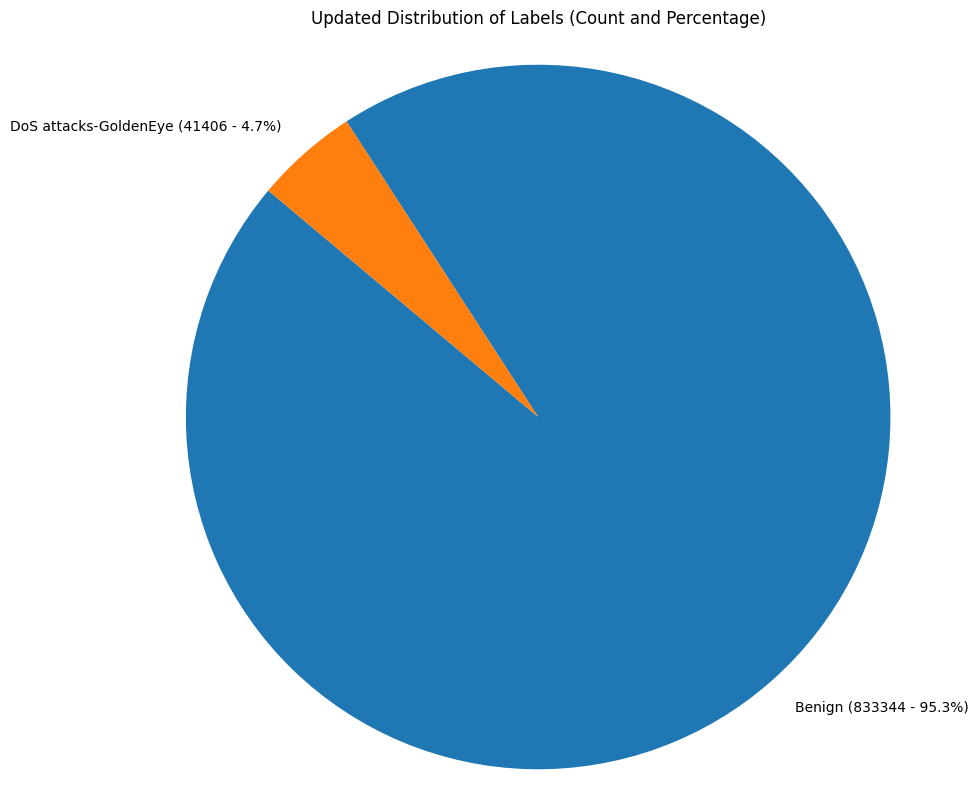

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This extensive cell prepares the training and testing datasets for an unsupervised anomaly detection benchmark. It samples benign records for training, creates hierarchical test sets with different anomaly rates (0.2%, 1%, 5%), and ensures no overlap between training and testing data. It also defines attack samples for different levels and verifies the integrity of the created datasets.

In [ ]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

# Separate benign and attack records from the main DataFrame
benign_records = df[df['Label'] == 'Benign'].copy()
attack_records_goldeneye = df[df['Label'] == 'DoS attacks-GoldenEye'].copy()

print("==================================================")
print("TRAINING DATA CREATION")
print("==================================================")

# 1. Create Training Dataset
# Randomly sample exactly 100,000 Benign samples for training
X_train_sampled_original_indices = benign_records.sample(n=100000, random_state=RANDOM_STATE)
X_train = X_train_sampled_original_indices.reset_index(drop=True)

# Store the original indices of the samples selected for training
train_benign_original_indices = X_train_sampled_original_indices.index

# Training features dataset: same as X_train but without the 'Label' column
X_train_features = X_train.drop(columns=['Label'], errors='ignore')

print(f"Training dataset shape: {X_train.shape}")

print(f"Training dataset (Benign) Label distribution:\n{X_train['Label'].value_counts()}\n")

print("Shape of X_train_features: ", X_train_features.shape)
print("Head of X_train_features:")
display(X_train_features.head())

print("==================================================")
print("TEST DATA CREATION")
print("==================================================")

# Filter out training benign samples from the pool of available benign samples for testing
# Use the stored original indices to ensure no overlap
benign_available_for_test = benign_records[~benign_records.index.isin(train_benign_original_indices)].copy()

# 2. Create Common Benign Test Set for 5% dataset
test_benign_5_percent_sampled = benign_available_for_test.sample(n=28500, random_state=RANDOM_STATE)
test_benign_5_percent = test_benign_5_percent_sampled.reset_index(drop=True)

# Store the original indices of benign samples used in the 5% test set
test_benign_5_percent_original_indices = test_benign_5_percent_sampled.index

# Additional benign samples for 1% dataset (29700 - 28500 = 1200)
benign_remaining_after_5_percent = benign_available_for_test[~benign_available_for_test.index.isin(test_benign_5_percent_original_indices)]
additional_benign_1_percent_sampled = benign_remaining_after_5_percent.sample(n=1200, random_state=RANDOM_STATE)
additional_benign_1_percent = additional_benign_1_percent_sampled.reset_index(drop=True)
test_benign_1_percent = pd.concat([test_benign_5_percent, additional_benign_1_percent]).reset_index(drop=True)

# Store the original indices of benign samples added for the 1% test set
test_benign_1_percent_additional_original_indices = additional_benign_1_percent_sampled.index


# Additional benign samples for 0.2% dataset (29940 - 29700 = 240)
benign_remaining_after_1_percent = benign_remaining_after_5_percent[~benign_remaining_after_5_percent.index.isin(test_benign_1_percent_additional_original_indices)]
additional_benign_02_percent_sampled = benign_remaining_after_1_percent.sample(n=240, random_state=RANDOM_STATE)
additional_benign_02_percent = additional_benign_02_percent_sampled.reset_index(drop=True)
test_benign_02_percent = pd.concat([test_benign_1_percent, additional_benign_02_percent]).reset_index(drop=True)


print(f"Common benign test set (28,500) shape: {test_benign_5_percent.shape}")
print(f"Benign test set for 1% attacks (29,700) shape: {test_benign_1_percent.shape}")
print(f"Benign test set for 0.2% attacks (29,940) shape: {test_benign_02_percent.shape}")

# 3. Create Attack Hierarchy
# Randomly sample 1500 DoS-GoldenEye records as the superset for all attack levels
attack_samples_level3_superset = attack_records_goldeneye.sample(n=1500, random_state=RANDOM_STATE).reset_index(drop=True)

# Level 1 attacks: 60 records, labeled 1
attacks_L1 = attack_samples_level3_superset.iloc[:60].copy()
attacks_L1['Label'] = 1

# Level 2 attacks: Add 240 new records (total 300), labeled 2
attacks_L2_additional = attack_samples_level3_superset.iloc[60:300].copy()
attacks_L2_additional['Label'] = 2
attacks_L2_full = pd.concat([attacks_L1, attacks_L2_additional]).reset_index(drop=True)

# Level 3 attacks: Add 1200 new records (total 1500), labeled 3
attacks_L3_additional = attack_samples_level3_superset.iloc[300:1500].copy()
attacks_L3_additional['Label'] = 3
attacks_L3_full = pd.concat([attacks_L1, attacks_L2_additional, attacks_L3_additional]).reset_index(drop=True)

print(f"Attack samples for 0.2% dataset (L1, 60 samples) shape: {attacks_L1.shape}")
print(f"Attack samples for 1% dataset (L1+L2, 300 samples) shape: {attacks_L2_full.shape}")
print(f"Attack samples for 5% dataset (L1+L2+L3, 1500 samples) shape: {attacks_L3_full.shape}")


# 4. Construct Test Datasets
# 0.2% dataset: 29,940 benign + 60 attacks (Label 1)
test_df_02 = pd.concat([test_benign_02_percent, attacks_L1]).reset_index(drop=True)

# 1% dataset: 29,700 benign + 60 attacks (Label 1) + 240 attacks (Label 2)
test_df_1 = pd.concat([test_benign_1_percent, attacks_L2_full]).reset_index(drop=True)

# 5% dataset: 28,500 benign + 60 attacks (Label 1) + 240 attacks (Label 2) + 1200 attacks (Label 3)
test_df_5 = pd.concat([test_benign_5_percent, attacks_L3_full]).reset_index(drop=True)

print("\nTest dataset shapes:")
print(f"  0.2% Test dataset shape: {test_df_02.shape}")
print(f"  1% Test dataset shape: {test_df_1.shape}")
print(f"  5% Test dataset shape: {test_df_5.shape}")

print("\nClass distributions:")
print("  0.2% Test dataset class distribution:\n" + str(test_df_02['Label'].value_counts()))
print("  1% Test dataset class distribution:\n" + str(test_df_1['Label'].value_counts()))
print("  5% Test dataset class distribution:\n" + str(test_df_5['Label'].value_counts()))

print("\nPercentage distributions:")
print("  0.2% Test dataset percentage distribution:\n" + str(test_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Test dataset percentage distribution:\n" + str(test_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Test dataset percentage distribution:\n" + str(test_df_5['Label'].value_counts(normalize=True) * 100))

print("\n==================================================")
print("VERIFICATION")
print("==================================================")

# Verification that train and test normal samples are disjoint
# Ensure comparison is done on relevant columns if 'Label' can vary after resetting index
overlap_train_test_benign = pd.merge(X_train.drop(columns=['Label'], errors='ignore'),
                                     test_benign_02_percent.drop(columns=['Label'], errors='ignore'),
                                     how='inner', on=list(df.drop(columns=['Label'], errors='ignore').columns)).shape[0]
print(f"Overlap between training benign and smallest test benign set: {overlap_train_test_benign} records. (Expected: 0)")

# Verification that benign test records are identical across test datasets (hierarchical requirement)
is_5_in_1 = test_benign_5_percent.shape[0] == pd.merge(test_benign_5_percent.drop(columns=['Label'], errors='ignore'),
                                                         test_benign_1_percent.drop(columns=['Label'], errors='ignore'),
                                                         on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_1_in_02 = test_benign_1_percent.shape[0] == pd.merge(test_benign_1_percent.drop(columns=['Label'], errors='ignore'),
                                                          test_benign_02_percent.drop(columns=['Label'], errors='ignore'),
                                                          on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all 5% benign samples in 1% benign samples? {is_5_in_1}")
print(f"Are all 1% benign samples in 0.2% benign samples? {is_1_in_02}")

# Verification that attack hierarchy is satisfied
is_L1_in_L2 = attacks_L1.drop(columns=['Label'], errors='ignore').shape[0] == pd.merge(attacks_L1.drop(columns=['Label'], errors='ignore'), attacks_L2_full.drop(columns=['Label'], errors='ignore'), on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3 = attacks_L2_full.drop(columns=['Label'], errors='ignore').shape[0] == pd.merge(attacks_L2_full.drop(columns=['Label'], errors='ignore'), attacks_L3_full.drop(columns=['Label'], errors='ignore'), on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks? {is_L1_in_L2}")
print(f"Are all Level 2 attacks in Level 3 attacks? {is_L2_in_L3}")

# Verify attack labels within each dataset
print("\nAttack label verification:")
print(f"  Labels in 0.2% test attacks: {attacks_L1['Label'].unique()}")
print(f"  Labels in 1% test attacks: {attacks_L2_full['Label'].unique()}")
print(f"  Labels in 5% test attacks: {attacks_L3_full['Label'].unique()}")

TRAINING DATA CREATION
Training dataset shape: (100000, 79)
Training dataset (Benign) Label distribution:
Label
Benign    100000
Name: count, dtype: int64

Shape of X_train_features:  (100000, 78)
Head of X_train_features:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,53,17,2843,1,1,43,143,43,43,43.0,...,0,8,0.0,0.0,0,0,0.0,0.0,0,0
1,443,6,827,1,2,0,0,0,0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,53,17,12761,1,1,50,137,50,50,50.0,...,0,8,0.0,0.0,0,0,0.0,0.0,0,0
3,53973,6,541730,2,1,0,0,0,0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,5355,17,418650,2,0,66,0,33,33,33.0,...,1,8,0.0,0.0,0,0,0.0,0.0,0,0


TEST DATA CREATION
Common benign test set (28,500) shape: (28500, 79)
Benign test set for 1% attacks (29,700) shape: (29700, 79)
Benign test set for 0.2% attacks (29,940) shape: (29940, 79)
Attack samples for 0.2% dataset (L1, 60 samples) shape: (60, 79)
Attack samples for 1% dataset (L1+L2, 300 samples) shape: (300, 79)
Attack samples for 5% dataset (L1+L2+L3, 1500 samples) shape: (1500, 79)

Test dataset shapes:
  0.2% Test dataset shape: (30000, 79)
  1% Test dataset shape: (30000, 79)
  5% Test dataset shape: (30000, 79)

Class distributions:
  0.2% Test dataset class distribution:
Label
Benign    29940
1            60
Name: count, dtype: int64
  1% Test dataset class distribution:
Label
Benign    29700
2           240
1            60
Name: count, dtype: int64
  5% Test dataset class distribution:
Label
Benign    28500
3          1200
2           240
1            60
Name: count, dtype: int64

Percentage distributions:
  0.2% Test dataset percentage distribution:
Label
Benign    99.

This cell sets up the environment for the anomaly detection benchmark. It imports necessary libraries, defines constants for experiments (e.g., Optuna trials, Autoencoder epochs), sets a random seed for reproducibility, and defines a `composite_score` function for hyperparameter optimization. It also includes warnings and TensorFlow availability checks.

Setup complete. TensorFlow available: True
All required variables found. Ready to build calibration sets.
Leftover benign pool for calibration: 703404 rows
Leftover attack pool for calibration: 39906 rows
Calibration set for 0.2% dataset: 15000 rows, 30 attacks (0.200% contamination)
Calibration set for 1% dataset: 15000 rows, 150 attacks (1.000% contamination)
Calibration set for 5% dataset: 15000 rows, 750 attacks (5.000% contamination)
Metrics utilities ready.
Preprocessing utilities ready.
Model wrappers ready.
Optuna functions ready.
Runner ready. Execute the next cell to run all 48 evaluations.
Skewness overview on training data:
  [MVN] 66/78 features exceed |skew|>0.75 (will be power-transformed)
  [IsolationForest] 66/78 features exceed |skew|>0.75 (left as-is: tree model is transform-invariant)
  [Autoencoder] 66/78 features exceed |skew|>0.75 (will be power-transformed)
  [OneClassSVM] 66/78 features exceed |skew|>0.75 (will be power-transformed)

[Exp 1 | MVN | 0.2%]  (1/48

,Experiment,Model,TestSet,SelectedFeatures,HPO,NumFeatures,NumDims,TrueContamination,BestParams,Precision,Recall,F1,FPR,FNR,TP,FP,FN,TN,RuntimeSec
0,1,MVN,0.2%,False,False,78,13,0.002,"{""reg_covar"": 0.001}",0.003729,0.866667,0.007427,0.463961,0.133333,52,13891,8,16049,12.71
1,1,MVN,1%,False,False,78,13,0.010,"{""reg_covar"": 0.001}",0.017180,0.803333,0.033640,0.464209,0.196667,241,13787,59,15913,11.46
2,1,MVN,5%,False,False,78,13,0.050,"{""reg_covar"": 0.001}",0.079493,0.761333,0.143956,0.464000,0.238667,1142,13224,358,15276,11.64
3,1,IsolationForest,0.2%,False,False,78,78,0.002,"{""n_estimators"": 200, ""max_samples"": ""auto"", ""...",0.000000,0.000000,0.000000,0.006747,1.000000,0,202,60,29738,6.51
4,1,IsolationForest,1%,False,False,78,78,0.010,"{""n_estimators"": 200, ""max_samples"": ""auto"", ""...",0.021860,0.813333,0.042575,0.367609,0.186667,244,10918,56,18782,4.84
5,1,IsolationForest,5%,False,False,78,78,0.050,"{""n_estimators"": 200, ""max_samples"": ""auto"", ""...",0.110961,0.766667,0.193864,0.323298,0.233333,1150,9214,350,19286,5.61
6,1,Autoencoder,0.2%,False,False,78,78,0.002,"{""encoding_dim"": 16, ""hidden_dim"": 32, ""learni...",0.068966,0.700000,0.125561,0.018938,0.300000,42,567,18,29373,61.50
7,1,Autoencoder,1%,False,False,78,78,0.010,"{""encoding_dim"": 16, ""hidden_dim"": 32, ""learni...",0.246835,0.910000,0.388336,0.028047,0.090000,273,833,27,28867,55.45
8,1,Autoencoder,5%,False,False,78,78,0.050,"{""encoding_dim"": 16, ""hidden_dim"": 32, ""learni...",0.536009,0.908000,0.674091,0.041368,0.092000,1362,1179,138,27321,56.23
9,1,OneClassSVM,0.2%,False,False,78,8,0.002,"{""nu"": 0.002, ""gamma"": ""scale"", ""kernel"": ""rbf""}",0.000000,0.000000,0.000000,0.033300,1.000000,0,997,60,28943,12.13


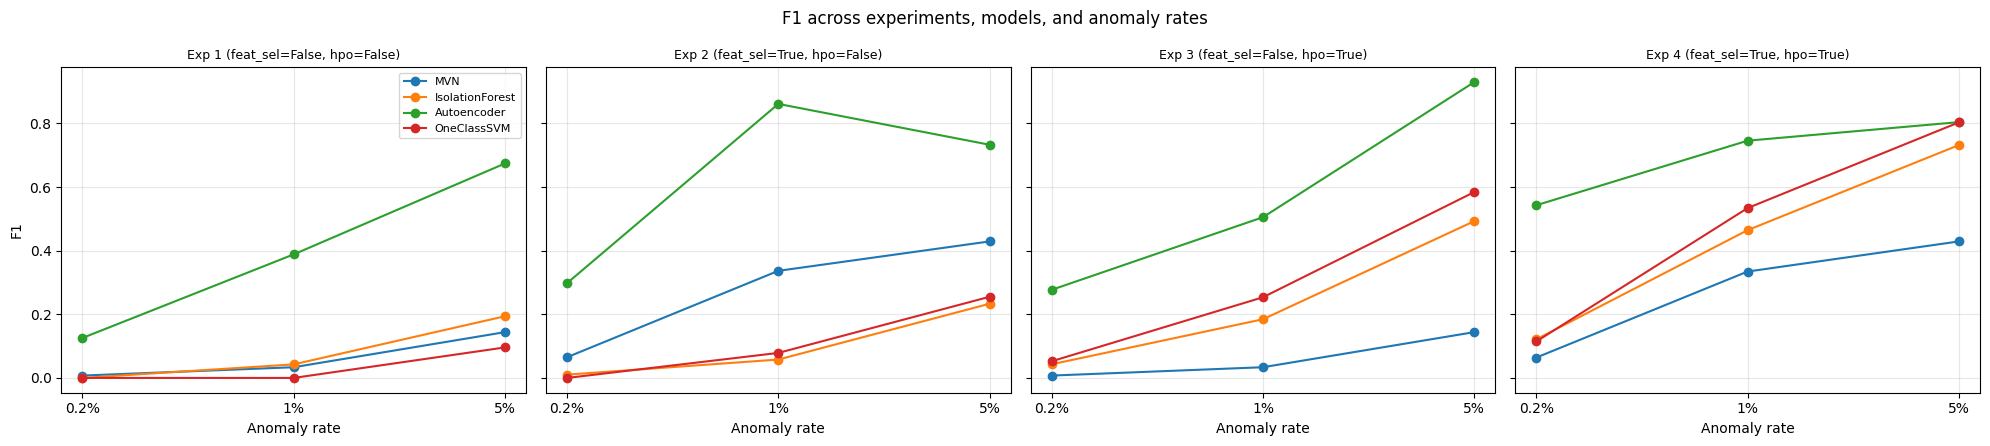

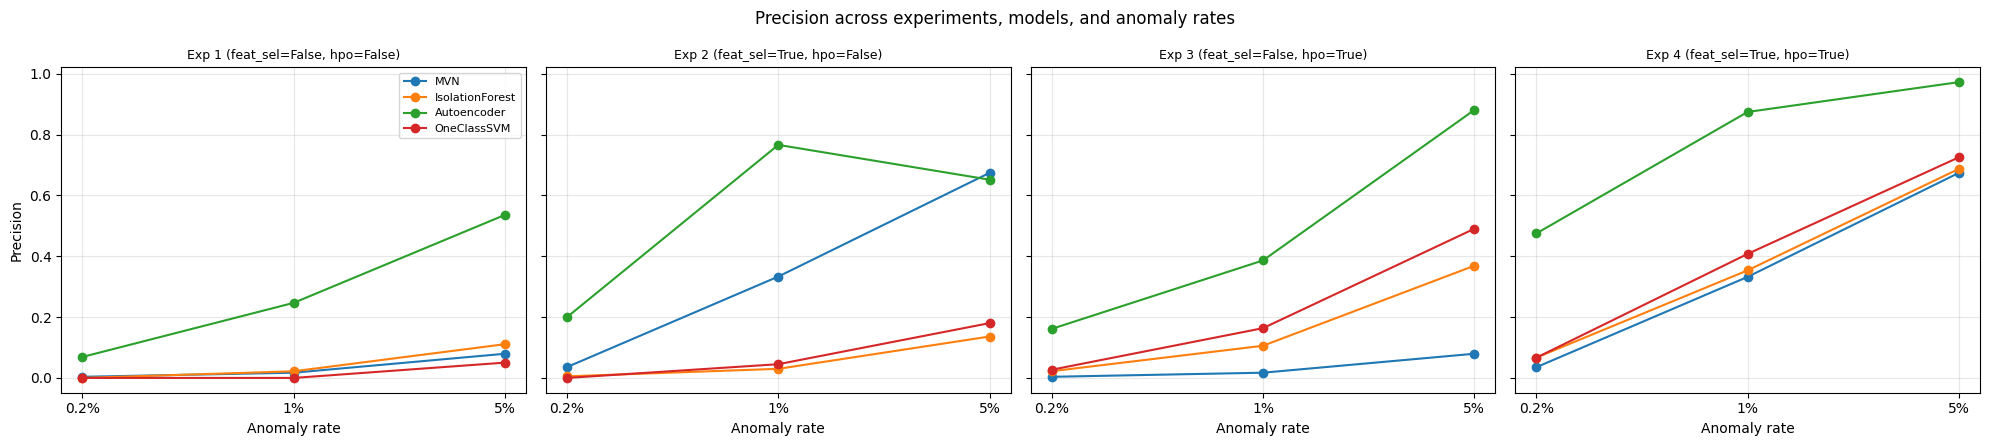

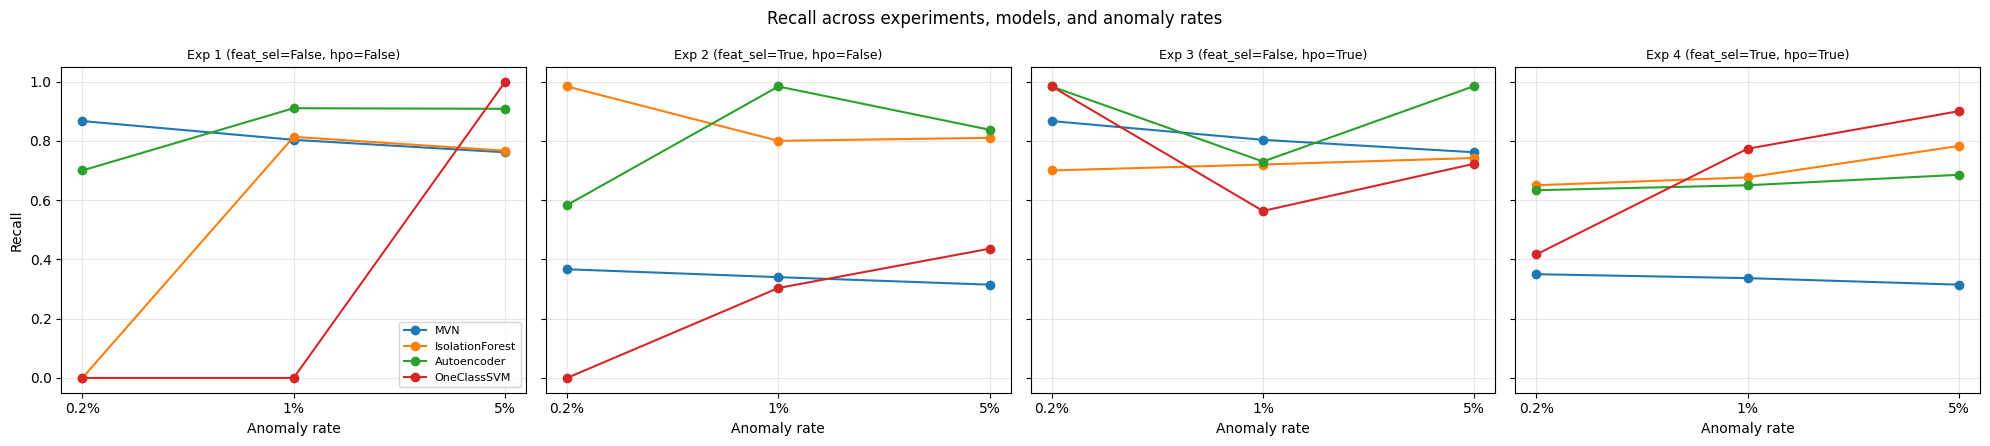

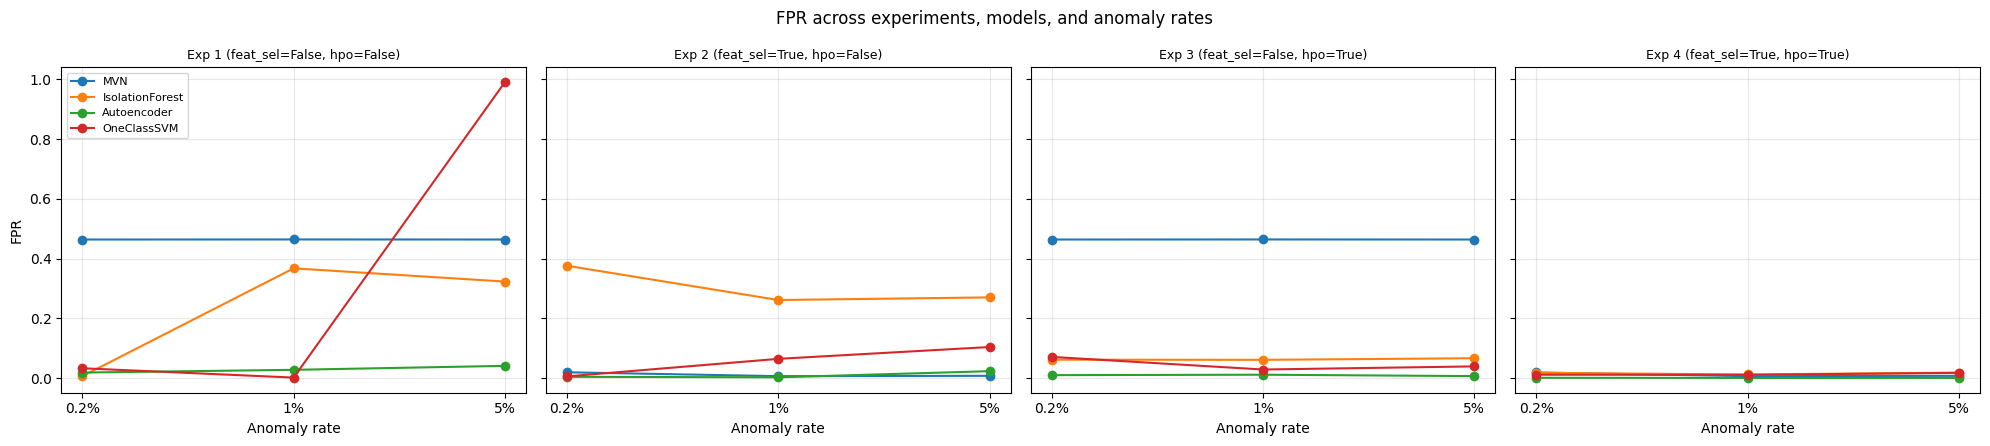

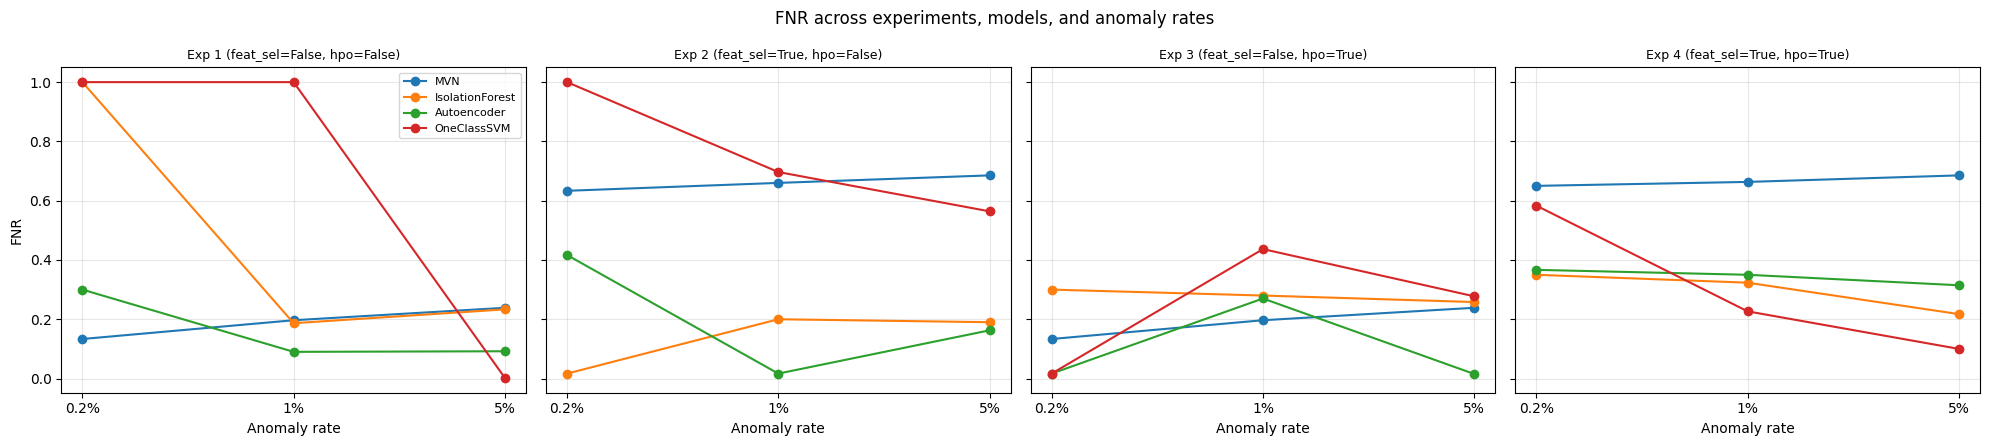


Best overall configuration per model (highest F1):


,Model,Experiment,TestSet,F1,Precision,Recall,FPR,FNR,BestParams
32,Autoencoder,3,5%,0.929808,0.880739,0.984667,0.007018,0.015333,"{""encoding_dim"": 64, ""hidden_dim"": 96, ""learni..."
41,IsolationForest,4,5%,0.731920,0.687354,0.782667,0.018737,0.217333,"{""n_estimators"": 125, ""max_samples"": 0.8735039..."
14,MVN,2,5%,0.429091,0.674286,0.314667,0.008000,0.685333,"{""reg_covar"": 0.001}"
47,OneClassSVM,4,5%,0.803332,0.725416,0.900000,0.017930,0.100000,"{""kernel"": ""rbf"", ""nu"": 0.021981612816208, ""ga..."


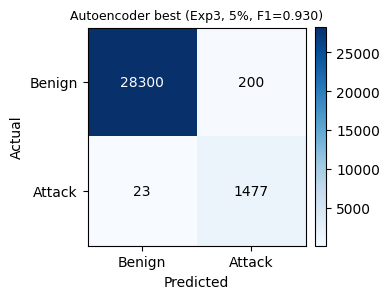

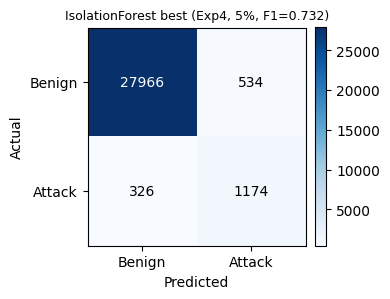

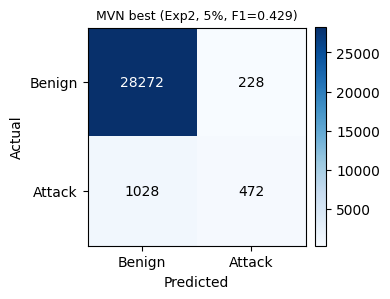

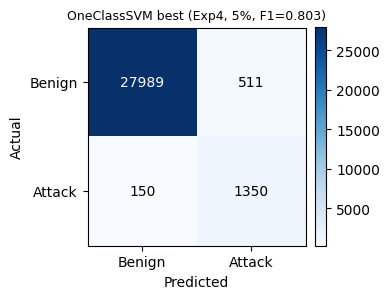

SUMMARY OF FINDINGS

-- Best model per anomaly rate (highest F1) --
  0.2%: Autoencoder (Exp 4) F1=0.5429 Precision=0.4750 Recall=0.6333 FPR=0.0014 FNR=0.3667
  1%: Autoencoder (Exp 2) F1=0.8613 Precision=0.7662 Recall=0.9833 FPR=0.0030 FNR=0.0167
  5%: Autoencoder (Exp 3) F1=0.9298 Precision=0.8807 Recall=0.9847 FPR=0.0070 FNR=0.0153

-- Effect of feature selection (avg F1) --
SelectedFeatures
False    0.217189
True     0.376997
Name: F1, dtype: float64

-- Effect of hyperparameter optimization (avg F1) --
HPO
False    0.210973
True     0.383212
Name: F1, dtype: float64

-- Average F1 per model across all 12 of its runs --
Model
Autoencoder        0.573733
OneClassSVM        0.230973
IsolationForest    0.214631
MVN                0.169034
Name: F1, dtype: float64

-- Robustness: F1 drop from 5% -> 0.2% anomaly rate (smaller = more robust) --


TestSet,0.2%,1%,5%,F1_drop
Model,,,,
MVN,0.035992,0.184588,0.286523,0.250531
IsolationForest,0.043638,0.187333,0.412921,0.369283
OneClassSVM,0.041763,0.216532,0.434623,0.392859
Autoencoder,0.310821,0.625134,0.785242,0.474421



Done. Full results in results_df / anomaly_benchmark_results_v2.csv


In [ ]:
# ============================================================================
# CICIDS2018 UNSUPERVISED ANOMALY DETECTION BENCHMARK - v2
# 4 Experiments x 4 Models x 3 Test datasets = 48 evaluations
#
# Continues DIRECTLY from your notebook (Untitled9.ipynb) - run this right
# after the cell that creates X_train, X_train_features, test_df_02,
# test_df_1, test_df_5, benign_records, attack_records_goldeneye, and the
# *_original_indices variables. No renaming needed.
#
# Paste each "# %% CELL N" block into its own Colab cell, in order.
# ============================================================================


# %% CELL 0 -------------------------------------------------------------
# SETUP
# -------------------------------------------------------------------------
import os, gc, time, json, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import skew

try:
    import optuna
except ImportError:
    os.system("pip -q install optuna")
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    tf.get_logger().setLevel("ERROR")
    tf.random.set_seed(42)
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("[WARN] TensorFlow unavailable -> Autoencoder will be skipped:", e)

SEED = 42
np.random.seed(SEED)

N_OPTUNA_TRIALS   = 20          # as requested
OCSVM_TRAIN_CAP   = 5000        # OCSVM does not scale to 100k rows on free Colab
AE_MAX_EPOCHS     = 40
AE_PATIENCE       = 5
SKEW_THRESHOLD    = 0.75        # |skew| above this -> feature gets power-transformed

# Composite Optuna objective: F1 is the main driver, small penalty keeps
# FPR/FNR down as a tie-breaker (matches "F1 high, FPR & FNR low" priority).
def composite_score(f1, fpr, fnr):
    return f1 - 0.10 * fpr - 0.05 * fnr

print("Setup complete. TensorFlow available:", TF_OK)


# %% CELL 1 -------------------------------------------------------------
# SANITY CHECK - confirms your notebook state has everything needed
# -------------------------------------------------------------------------
REQUIRED_VARS = [
    "X_train_features", "test_df_02", "test_df_1", "test_df_5",
    "benign_records", "attack_records_goldeneye",
    "train_benign_original_indices", "test_benign_5_percent_original_indices",
    "test_benign_1_percent_additional_original_indices",
    "additional_benign_02_percent_sampled", "RANDOM_STATE",
]
missing = [v for v in REQUIRED_VARS if v not in globals()]
if missing:
    raise NameError(
        f"Missing variables from your earlier cells: {missing}\n"
        "Run the dataset-preparation cell (the one that builds X_train, "
        "test_df_02/1/5, benign_records, attack_records_goldeneye, etc.) "
        "before this pipeline."
    )
print("All required variables found. Ready to build calibration sets.")


# %% CELL 2 -------------------------------------------------------------
# PER-DATASET, CONTAMINATION-MATCHED CALIBRATION SETS
# -------------------------------------------------------------------------
# Each of the 3 test sets gets its OWN isolated calibration set at the SAME
# contamination rate, drawn only from rows never used in training or in any
# test set. This is what lets us tune thresholds / hyperparameters "per
# dataset, corresponding to its contamination rate" without ever peeking at
# the actual test set.

TEST_SETS = {"0.2%": test_df_02, "1%": test_df_1, "5%": test_df_5}
TRUE_RATES = {"0.2%": 0.002, "1%": 0.01, "5%": 0.05}

# rows already spent on train / test benign
used_benign_idx = (
    train_benign_original_indices
    .union(test_benign_5_percent_original_indices)
    .union(test_benign_1_percent_additional_original_indices)
    .union(additional_benign_02_percent_sampled.index)
)
leftover_benign = benign_records.drop(index=used_benign_idx, errors="ignore")

# rows already spent on the 1500-row attack superset (regenerate with the
# same seed to recover their original index, since the notebook reset it)
used_attack_idx = attack_records_goldeneye.sample(
    n=1500, random_state=RANDOM_STATE
).index
leftover_attack = attack_records_goldeneye.drop(index=used_attack_idx, errors="ignore")

print(f"Leftover benign pool for calibration: {len(leftover_benign)} rows")
print(f"Leftover attack pool for calibration: {len(leftover_attack)} rows")


def build_calibration_set(rate, n_total=15000, seed=RANDOM_STATE):
    n_attack = max(10, round(rate * n_total))
    n_benign = n_total - n_attack
    n_benign = min(n_benign, len(leftover_benign))
    n_attack = min(n_attack, len(leftover_attack))

    cal_benign = leftover_benign.sample(n=n_benign, random_state=seed).copy()
    cal_attack = leftover_attack.sample(n=n_attack, random_state=seed).copy()
    cal_benign["Label"] = "Benign"
    cal_attack["Label"] = "Attack"
    cal_df = pd.concat([cal_benign, cal_attack]).sample(frac=1, random_state=seed)
    return cal_df.reset_index(drop=True)


CAL_SETS = {}
for name, rate in TRUE_RATES.items():
    cal_df = build_calibration_set(rate)
    n_att = (cal_df["Label"] != "Benign").sum()
    print(f"Calibration set for {name} dataset: {cal_df.shape[0]} rows, "
          f"{n_att} attacks ({100*n_att/len(cal_df):.3f}% contamination)")
    CAL_SETS[name] = cal_df


# %% CELL 3 -------------------------------------------------------------
# LABEL BINARIZATION + METRICS + CONFUSION MATRIX (exactly what was asked for)
# -------------------------------------------------------------------------

def binarize(df):
    """0 = Benign, 1 = Attack. Works whether the attack label is a string
    ('DoS attacks-GoldenEye'/'Attack') or the hierarchical ints 1/2/3 used
    in test_df_02/1/5."""
    y = (df["Label"].astype(str) != "Benign").astype(int).values
    X = df.drop(columns=["Label"]).select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    return X, y


def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return {"Precision": precision, "Recall": recall, "F1": f1,
            "FPR": fpr, "FNR": fnr,
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}


def print_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\nConfusion matrix - {title}")
    print(f"{'':15}{'Pred: Benign':>15}{'Pred: Attack':>15}")
    print(f"{'Actual: Benign':15}{cm[0,0]:>15}{cm[0,1]:>15}")
    print(f"{'Actual: Attack':15}{cm[1,0]:>15}{cm[1,1]:>15}")


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Attack"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


def best_threshold(scores, y_true, n_steps=250):
    lo, hi = np.percentile(scores, 0.5), np.percentile(scores, 99.9)
    cands = np.linspace(lo, hi, n_steps)
    best_c, best_t = -1, cands[0]
    for t in cands:
        pred = (scores > t).astype(int)
        m = compute_metrics(y_true, pred)
        c = composite_score(m["F1"], m["FPR"], m["FNR"])
        if c > best_c:
            best_c, best_t = c, t
    return best_t, best_c


print("Metrics utilities ready.")


# %% CELL 4 -------------------------------------------------------------
# SKEWNESS CHECK + PER-MODEL SCALING / DIM-REDUCTION / FEATURE SELECTION
# -------------------------------------------------------------------------

MODEL_USE_POWER_TRANSFORM = {
    "MVN": True, "IsolationForest": False, "Autoencoder": True, "OneClassSVM": True,
}
MODEL_SCALERS = {
    "MVN": StandardScaler, "IsolationForest": RobustScaler,
    "Autoencoder": MinMaxScaler, "OneClassSVM": StandardScaler,
}
MODEL_USE_PCA = {
    "MVN": True, "IsolationForest": False, "Autoencoder": False, "OneClassSVM": True,
}
MODEL_PCA_VARIANCE = {"MVN": 0.95, "OneClassSVM": 0.90}
N_SELECTED_FEATURES = {
    "MVN": 20, "IsolationForest": 30, "Autoencoder": 35, "OneClassSVM": 20,
}


def report_skewness(X_train_df, model_name):
    sk = X_train_df.apply(lambda c: skew(c.dropna()))
    n_skewed = (sk.abs() > SKEW_THRESHOLD).sum()
    print(f"  [{model_name}] {n_skewed}/{len(sk)} features exceed "
          f"|skew|>{SKEW_THRESHOLD} "
          f"({'will be power-transformed' if MODEL_USE_POWER_TRANSFORM[model_name] else 'left as-is: tree model is transform-invariant'})")


def select_features(X_cal, y_cal, model_name, use_selection):
    if not use_selection:
        return list(X_cal.columns)
    k = min(N_SELECTED_FEATURES[model_name], X_cal.shape[1])
    vt = VarianceThreshold(threshold=1e-8).fit(X_cal)
    kept = X_cal.columns[vt.get_support()]
    mi = mutual_info_classif(X_cal[kept], y_cal, random_state=SEED)
    ranked = pd.Series(mi, index=kept).sort_values(ascending=False)
    return list(ranked.head(k).index)


def preprocess_for_model(model_name, X_train, X_cal, X_test, feature_cols):
    Xtr, Xcal, Xte = (X_train[feature_cols].values, X_cal[feature_cols].values,
                       X_test[feature_cols].values)

    pt = None
    if MODEL_USE_POWER_TRANSFORM[model_name]:
        pt = PowerTransformer(method="yeo-johnson")
        Xtr = pt.fit_transform(Xtr)
        Xcal = pt.transform(Xcal)
        Xte = pt.transform(Xte)

    scaler = MODEL_SCALERS[model_name]()
    Xtr = scaler.fit_transform(Xtr)
    Xcal = scaler.transform(Xcal)
    Xte = scaler.transform(Xte)

    pca = None
    if MODEL_USE_PCA.get(model_name, False):
        pca = PCA(n_components=MODEL_PCA_VARIANCE[model_name], random_state=SEED)
        Xtr = pca.fit_transform(Xtr)
        Xcal = pca.transform(Xcal)
        Xte = pca.transform(Xte)

    return Xtr, Xcal, Xte, Xtr.shape[1]


print("Preprocessing utilities ready.")


# %% CELL 5 -------------------------------------------------------------
# MODEL WRAPPERS
# -------------------------------------------------------------------------

class MVNDetector:
    def __init__(self, reg_covar=1e-3):
        self.reg_covar = reg_covar
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        cov = LedoitWolf().fit(X).covariance_
        cov = cov + np.eye(cov.shape[0]) * self.reg_covar
        self.cov_inv_ = np.linalg.pinv(cov)
        return self
    def score(self, X):
        diff = X - self.mean_
        return np.einsum("ij,jk,ik->i", diff, self.cov_inv_, diff)


class IForestDetector:
    def __init__(self, n_estimators=200, max_samples="auto",
                 max_features=1.0, contamination="auto"):
        self.model = IsolationForest(
            n_estimators=n_estimators, max_samples=max_samples,
            max_features=max_features, contamination=contamination,
            random_state=SEED, n_jobs=-1,
        )
    def fit(self, X):
        self.model.fit(X); return self
    def score(self, X):
        return -self.model.decision_function(X)


class OCSVMDetector:
    def __init__(self, nu=0.05, gamma="scale", kernel="rbf", train_cap=OCSVM_TRAIN_CAP):
        self.nu, self.gamma, self.kernel, self.train_cap = nu, gamma, kernel, train_cap
    def fit(self, X):
        if X.shape[0] > self.train_cap:
            rng = np.random.RandomState(SEED)
            idx = rng.choice(X.shape[0], self.train_cap, replace=False)
            X = X[idx]
        self.model = OneClassSVM(nu=self.nu, gamma=self.gamma, kernel=self.kernel)
        self.model.fit(X); return self
    def score(self, X):
        return -self.model.decision_function(X)


class AutoencoderDetector:
    def __init__(self, encoding_dim=16, hidden_dim=32, learning_rate=1e-3,
                 dropout=0.0, batch_size=256, epochs=AE_MAX_EPOCHS):
        self.encoding_dim, self.hidden_dim = encoding_dim, hidden_dim
        self.learning_rate, self.dropout = learning_rate, dropout
        self.batch_size, self.epochs = batch_size, epochs

    def _build(self, input_dim):
        inp = layers.Input(shape=(input_dim,))
        x = layers.Dense(self.hidden_dim, activation="relu")(inp)
        if self.dropout > 0:
            x = layers.Dropout(self.dropout)(x)
        code = layers.Dense(self.encoding_dim, activation="relu")(x)
        x = layers.Dense(self.hidden_dim, activation="relu")(code)
        out = layers.Dense(input_dim, activation="sigmoid")(x)
        m = models.Model(inp, out)
        m.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate), loss="mse")
        return m

    def fit(self, X):
        if not TF_OK:
            raise RuntimeError("TensorFlow not available.")
        self.model = self._build(X.shape[1])
        Xtr, Xval = train_test_split(X, test_size=0.1, random_state=SEED)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=AE_PATIENCE,
                                      restore_best_weights=True)
        self.model.fit(Xtr, Xtr, validation_data=(Xval, Xval),
                        epochs=self.epochs, batch_size=self.batch_size,
                        verbose=0, callbacks=[es])
        return self

    def score(self, X):
        recon = self.model.predict(X, verbose=0)
        return np.mean(np.square(X - recon), axis=1)


def build_model(model_name, params):
    return {"MVN": MVNDetector, "IsolationForest": IForestDetector,
            "OneClassSVM": OCSVMDetector, "Autoencoder": AutoencoderDetector}[model_name](**params)


print("Model wrappers ready.")


# %% CELL 6 -------------------------------------------------------------
# OPTUNA SEARCH SPACES - 20 trials, wide ranges, contamination-anchored
# -------------------------------------------------------------------------

def clip_rate(r):
    return float(np.clip(r, 0.001, 0.5))


def optuna_objective(trial, model_name, Xtr, Xcal, y_cal, true_rate):
    if model_name == "MVN":
        reg = trial.suggest_float("reg_covar", 1e-6, 1.0, log=True)
        model = MVNDetector(reg_covar=reg).fit(Xtr)

    elif model_name == "IsolationForest":
        n_estimators = trial.suggest_int("n_estimators", 50, 500, step=25)
        max_samples = trial.suggest_float("max_samples", 0.2, 1.0)
        max_features = trial.suggest_float("max_features", 0.3, 1.0)
        rate_mult = trial.suggest_float("contamination_multiplier", 0.2, 5.0, log=True)
        contamination = clip_rate(true_rate * rate_mult)
        model = IForestDetector(n_estimators=n_estimators, max_samples=max_samples,
                                 max_features=max_features,
                                 contamination=contamination).fit(Xtr)

    elif model_name == "OneClassSVM":
        rate_mult = trial.suggest_float("nu_multiplier", 0.2, 5.0, log=True)
        nu = clip_rate(true_rate * rate_mult)
        gamma_choice = trial.suggest_categorical("gamma_mode", ["scale", "auto", "float"])
        gamma = (trial.suggest_float("gamma_value", 1e-4, 10.0, log=True)
                 if gamma_choice == "float" else gamma_choice)
        kernel = trial.suggest_categorical("kernel", ["rbf", "sigmoid"])
        model = OCSVMDetector(nu=nu, gamma=gamma, kernel=kernel).fit(Xtr)

    elif model_name == "Autoencoder":
        encoding_dim = trial.suggest_categorical("encoding_dim", [4, 8, 16, 24, 32, 64])
        hidden_dim = trial.suggest_categorical("hidden_dim", [16, 32, 48, 64, 96, 128])
        lr = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3)
        model = AutoencoderDetector(encoding_dim=encoding_dim, hidden_dim=hidden_dim,
                                     learning_rate=lr, dropout=dropout).fit(Xtr)
    else:
        raise ValueError(model_name)

    scores_cal = model.score(Xcal)
    _, best_c = best_threshold(scores_cal, y_cal)
    return best_c


def run_optuna(model_name, Xtr, Xcal, y_cal, true_rate, n_trials=N_OPTUNA_TRIALS):
    study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(
        lambda tr: optuna_objective(tr, model_name, Xtr, Xcal, y_cal, true_rate),
        n_trials=n_trials, catch=(Exception,), show_progress_bar=False,
    )
    return study.best_params


def default_params(model_name, true_rate):
    """Sensible, contamination-aware defaults used when HPO is off."""
    rate = clip_rate(true_rate)
    if model_name == "MVN":
        return {"reg_covar": 1e-3}
    if model_name == "IsolationForest":
        return {"n_estimators": 200, "max_samples": "auto",
                 "max_features": 1.0, "contamination": rate}
    if model_name == "OneClassSVM":
        return {"nu": rate, "gamma": "scale", "kernel": "rbf"}
    if model_name == "Autoencoder":
        return {"encoding_dim": 16, "hidden_dim": 32, "learning_rate": 1e-3}
    raise ValueError(model_name)


def params_from_optuna(model_name, raw):
    """Translate Optuna's raw trial params into the model's constructor kwargs."""
    if model_name == "IsolationForest":
        # contamination_multiplier is combined with the dataset's true_rate
        # at call time (see run_single_evaluation) -> handled there.
        return raw
    if model_name == "OneClassSVM":
        return raw
    return raw


print("Optuna functions ready.")


# %% CELL 7 -------------------------------------------------------------
# MAIN EXPERIMENT RUNNER
# -------------------------------------------------------------------------

EXPERIMENTS = {
    1: {"selected_features": False, "hpo": False},
    2: {"selected_features": True,  "hpo": False},
    3: {"selected_features": False, "hpo": True},
    4: {"selected_features": True,  "hpo": True},
}
MODEL_NAMES = ["MVN", "IsolationForest", "Autoencoder", "OneClassSVM"]


def finalize_params(model_name, raw_params, true_rate, hpo):
    """Turns either default_params or Optuna raw params into clean kwargs
    for the model constructor, resolving contamination/nu from the
    multiplier + the dataset's true rate."""
    if not hpo:
        return raw_params

    if model_name == "IsolationForest":
        mult = raw_params.pop("contamination_multiplier")
        raw_params["contamination"] = clip_rate(true_rate * mult)
        return raw_params

    if model_name == "OneClassSVM":
        mult = raw_params.pop("nu_multiplier")
        raw_params["nu"] = clip_rate(true_rate * mult)
        gamma_mode = raw_params.pop("gamma_mode")
        if gamma_mode == "float":
            raw_params["gamma"] = raw_params.pop("gamma_value")
        else:
            raw_params["gamma"] = gamma_mode
            raw_params.pop("gamma_value", None)
        return raw_params

    return raw_params


def run_single_evaluation(exp_id, model_name, test_name,
                           X_train_full, test_raw_df):
    cfg = EXPERIMENTS[exp_id]
    true_rate = TRUE_RATES[test_name]
    cal_df = CAL_SETS[test_name]
    X_cal_full, y_cal = binarize(cal_df)
    X_test_full, y_test = binarize(test_raw_df)

    if model_name == "Autoencoder" and not TF_OK:
        print("  [SKIP] Autoencoder unavailable (no TensorFlow).")
        return None

    feature_cols = select_features(X_cal_full, y_cal, model_name, cfg["selected_features"])
    Xtr, Xcal, Xte, n_dims = preprocess_for_model(
        model_name, X_train_full, X_cal_full, X_test_full, feature_cols
    )

    if cfg["hpo"]:
        raw_params = run_optuna(model_name, Xtr, Xcal, y_cal, true_rate)
    else:
        raw_params = default_params(model_name, true_rate)

    final_params = finalize_params(model_name, dict(raw_params), true_rate, cfg["hpo"])
    model = build_model(model_name, final_params)
    model.fit(Xtr)

    cal_scores = model.score(Xcal)
    threshold, _ = best_threshold(cal_scores, y_cal)

    test_scores = model.score(Xte)
    y_pred = (test_scores > threshold).astype(int)
    metrics = compute_metrics(y_test, y_pred)

    result = {
        "Experiment": exp_id, "Model": model_name, "TestSet": test_name,
        "SelectedFeatures": cfg["selected_features"], "HPO": cfg["hpo"],
        "NumFeatures": len(feature_cols), "NumDims": n_dims,
        "TrueContamination": true_rate,
        "BestParams": json.dumps(final_params, default=str),
        **metrics,
    }
    return result, y_test, y_pred


def run_all_experiments():
    X_train_full = X_train_features.copy()
    X_train_full = X_train_full.select_dtypes(include=[np.number])
    X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
    X_train_full = X_train_full.fillna(X_train_full.median(numeric_only=True))

    print("Skewness overview on training data:")
    for m in MODEL_NAMES:
        report_skewness(X_train_full, m)

    all_results, raw_preds = [], {}
    total = len(EXPERIMENTS) * len(MODEL_NAMES) * len(TEST_SETS)
    count, t0 = 0, time.time()

    for exp_id in EXPERIMENTS:
        for model_name in MODEL_NAMES:
            for test_name, test_raw_df in TEST_SETS.items():
                count += 1
                tag = f"[Exp {exp_id} | {model_name} | {test_name}]"
                print(f"\n{'='*72}\n{tag}  ({count}/{total})")
                try:
                    t1 = time.time()
                    out = run_single_evaluation(exp_id, model_name, test_name,
                                                 X_train_full, test_raw_df)
                    if out is None:
                        continue
                    result, y_true, y_pred = out
                    result["RuntimeSec"] = round(time.time() - t1, 2)
                    all_results.append(result)
                    raw_preds[(exp_id, model_name, test_name)] = (y_true, y_pred)

                    print(f"  Features: {result['NumFeatures']} "
                          f"(dims after transform: {result['NumDims']}) | "
                          f"Params: {result['BestParams']}")
                    print(f"  Precision={result['Precision']:.4f}  "
                          f"Recall={result['Recall']:.4f}  F1={result['F1']:.4f}  "
                          f"FPR={result['FPR']:.4f}  FNR={result['FNR']:.4f}  "
                          f"({result['RuntimeSec']}s)")
                    print_confusion(y_true, y_pred, tag)
                except Exception as e:
                    print(f"  [ERROR] {tag} failed and was skipped: {e}")
                    traceback.print_exc()
                finally:
                    gc.collect()

    print(f"\nAll evaluations finished in {round((time.time()-t0)/60, 1)} min.")
    return pd.DataFrame(all_results), raw_preds


print("Runner ready. Execute the next cell to run all 48 evaluations.")


# %% CELL 8 -------------------------------------------------------------
# RUN EVERYTHING
# -------------------------------------------------------------------------
results_df, raw_preds = run_all_experiments()
results_df.to_csv("/content/anomaly_benchmark_results_v2.csv", index=False)
print("\nSaved to /content/anomaly_benchmark_results_v2.csv")
display(results_df)


# %% CELL 9 -------------------------------------------------------------
# LINE GRAPHS + BEST CONFIGURATIONS
# -------------------------------------------------------------------------

def plot_metric_lines(results_df, metric):
    test_order = ["0.2%", "1%", "5%"]
    fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(20, 4.5), sharey=True)
    for i, exp_id in enumerate(EXPERIMENTS):
        ax = axes[i]
        sub = results_df[results_df["Experiment"] == exp_id]
        for model_name in MODEL_NAMES:
            m = sub[sub["Model"] == model_name].set_index("TestSet").reindex(test_order)
            if m[metric].isnull().all():
                continue
            ax.plot(test_order, m[metric], marker="o", label=model_name)
        cfg = EXPERIMENTS[exp_id]
        ax.set_title(f"Exp {exp_id} (feat_sel={cfg['selected_features']}, "
                      f"hpo={cfg['hpo']})", fontsize=9)
        ax.set_xlabel("Anomaly rate")
        if i == 0:
            ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
    axes[0].legend(loc="best", fontsize=8)
    fig.suptitle(f"{metric} across experiments, models, and anomaly rates")
    plt.tight_layout(); plt.show()


for metric in ["F1", "Precision", "Recall", "FPR", "FNR"]:
    plot_metric_lines(results_df, metric)

best_per_model = results_df.loc[results_df.groupby("Model")["F1"].idxmax()]
print("\nBest overall configuration per model (highest F1):")
display(best_per_model[["Model", "Experiment", "TestSet", "F1", "Precision",
                         "Recall", "FPR", "FNR", "BestParams"]])

for _, row in best_per_model.iterrows():
    key = (row["Experiment"], row["Model"], row["TestSet"])
    if key in raw_preds:
        y_true, y_pred = raw_preds[key]
        plot_confusion(y_true, y_pred,
                        f"{row['Model']} best (Exp{row['Experiment']}, "
                        f"{row['TestSet']}, F1={row['F1']:.3f})")


# %% CELL 10 ------------------------------------------------------------
# SUMMARY OF FINDINGS
# -------------------------------------------------------------------------

print("="*78); print("SUMMARY OF FINDINGS"); print("="*78)

print("\n-- Best model per anomaly rate (highest F1) --")
for test_name in ["0.2%", "1%", "5%"]:
    sub = results_df[results_df["TestSet"] == test_name]
    if sub.empty:
        continue
    best = sub.loc[sub["F1"].idxmax()]
    print(f"  {test_name}: {best['Model']} (Exp {best['Experiment']}) "
          f"F1={best['F1']:.4f} Precision={best['Precision']:.4f} "
          f"Recall={best['Recall']:.4f} FPR={best['FPR']:.4f} FNR={best['FNR']:.4f}")

print("\n-- Effect of feature selection (avg F1) --")
print(results_df.groupby("SelectedFeatures")["F1"].mean())

print("\n-- Effect of hyperparameter optimization (avg F1) --")
print(results_df.groupby("HPO")["F1"].mean())

print("\n-- Average F1 per model across all 12 of its runs --")
print(results_df.groupby("Model")["F1"].mean().sort_values(ascending=False))

print("\n-- Robustness: F1 drop from 5% -> 0.2% anomaly rate (smaller = more robust) --")
pivot = results_df.pivot_table(index="Model", columns="TestSet", values="F1", aggfunc="mean")
if {"5%", "0.2%"}.issubset(pivot.columns):
    pivot["F1_drop"] = pivot["5%"] - pivot["0.2%"]
    display(pivot.sort_values("F1_drop"))

print("\nDone. Full results in results_df / anomaly_benchmark_results_v2.csv")

This cell specifically plots the F1 scores of the Autoencoder model across different anomaly rates (0.2%, 1%, and 5%). It showcases the Autoencoder's performance trend as the anomaly contamination in the dataset varies.

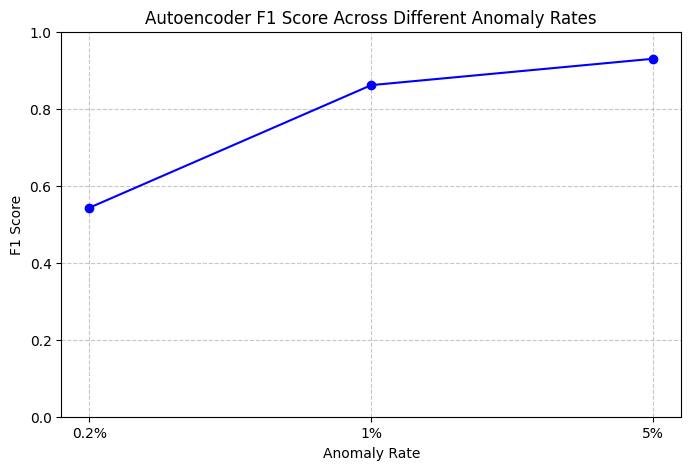

In [ ]:
import matplotlib.pyplot as plt

anomaly_rates = ['0.2%', '1%', '5%']
f1_scores = [
    0.5429, # Autoencoder (Exp 4) for 0.2%
    0.8613, # Autoencoder (Exp 2) for 1%
    0.9298  # Autoencoder (Exp 3) for 5%
]

plt.figure(figsize=(8, 5))
plt.plot(anomaly_rates, f1_scores, marker='o', linestyle='-', color='blue')
plt.title('Autoencoder F1 Score Across Different Anomaly Rates')
plt.xlabel('Anomaly Rate')
plt.ylabel('F1 Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.0) # F1 scores are typically between 0 and 1
plt.show()